In [1]:
"""
================================================================================
ADVERSARIAL ATTACK CASE STUDY: LOGISTIC REGRESSION ON SPAM CLASSIFICATION
================================================================================
This script demonstrates how a simple adversarial attack (similar in spirit
to Madry et al.'s adversarial training framework) can reduce the accuracy
of a Logistic Regression spam classifier.

The attack strategy: For text classification with TF-IDF + Logistic Regression,
we craft adversarial examples by modifying the TF-IDF feature vectors in the
direction that maximally flips the model's prediction (gradient-based attack).

Requirements: pip install scikit-learn pandas numpy
"""

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

### **STEP 1: LOAD SPAM DATASET**

In [2]:
print("=" * 70)
print("ADVERSARIAL ATTACK CASE STUDY: LOGISTIC REGRESSION ON SPAM DATA")
print("=" * 70)

df = pd.read_csv('/content/spam.csv', encoding='latin-1')
df = df[['v1', 'v2']].rename(columns={'v1': 'label', 'v2': 'text'})


# Encode labels: ham=0, spam=1
df['y'] = df['label'].map({'ham': 0, 'spam': 1})
print(f"\nDataset shape: {df.shape}")
print(f"Class distribution:\n{df['label'].value_counts()}")


ADVERSARIAL ATTACK CASE STUDY: LOGISTIC REGRESSION ON SPAM DATA

Dataset shape: (5572, 3)
Class distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


### **STEP 2: PREPROCESS & VECTORIZE**

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    df['text'], df['y'], test_size=0.2, random_state=42, stratify=df['y']
)

# TF-IDF vectorization (sparse matrix)
vectorizer = TfidfVectorizer(max_features=3000, stop_words='english')
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print(f"\n[+] TF-IDF matrix shape: {X_test_vec.shape}")
print(f"[+] Features: {X_test_vec.shape[1]} words")


[+] TF-IDF matrix shape: (1115, 3000)
[+] Features: 3000 words


### **STEP 3: TRAIN LOGISTIC REGRESSION**

In [4]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_vec, y_train)

# Clean accuracy
y_pred_clean = model.predict(X_test_vec)
acc_clean = accuracy_score(y_test, y_pred_clean)
print(f"\n{'='*70}")
print(f"CLEAN MODEL PERFORMANCE")
print(f"{'='*70}")
print(f"Accuracy: {acc_clean:.4f} ({acc_clean*100:.2f}%)")


CLEAN MODEL PERFORMANCE
Accuracy: 0.9722 (97.22%)


### **STEP 4: ADVERSARIAL ATTACK (FGSM-like for Logistic Regression)**
as the normal fgsm (fast gradient sign method ) used with images , we will adapt it to match the text data also so we named it FGSM-like


In [5]:
"""
ATTACK STRATEGY:
For Logistic Regression: p = sigmoid(W*x + b)
The gradient of loss w.r.t. input x is: ∇_x L = (p - y) * W

To flip prediction from spam(1) to ham(0):
- We want to DECREASE the logit score
- Move x in direction of -sign(W) for spam examples
- Move x in direction of +sign(W) for ham examples

This is essentially a Fast Gradient Sign Method (FGSM) adapted
for sparse TF-IDF features.
"""

def craft_adversarial_examples(X, y, model, vectorizer, epsilon=0.3):
    """
    Craft adversarial TF-IDF vectors by perturbing in the gradient direction.

    Args:
        X: sparse TF-IDF matrix (test set)
        y: true labels
        model: trained LogisticRegression
        epsilon: perturbation magnitude

    Returns:
        X_adv: adversarial sparse matrix
    """
    X = X.copy().tocsc()  # Convert to CSC for efficient column access
    weights = model.coef_[0]  # Shape: (n_features,)

    # For each sample, perturb features to flip prediction
    for i in range(X.shape[0]):
        # Get current prediction probability
        z = X[i].dot(weights.T) + model.intercept_[0]
        p = 1 / (1 + np.exp(-z))

        # Determine attack direction
        # If true label is spam (1), we want model to predict ham (0)
        # So we decrease the logit: subtract epsilon * sign(W)
        # If true label is ham (0), we want model to predict spam (1)
        # So we increase the logit: add epsilon * sign(W)

        if y[i] == 1:  # True spam -> attack to predict ham
            direction = -1
        else:  # True ham -> attack to predict spam
            direction = 1

        # Get non-zero feature indices for this sample
        row = X[i]
        _, cols = row.nonzero()

        # Perturb each feature
        for j in cols:
            # Gradient direction: sign of weight
            grad_sign = np.sign(weights[j])
            # Perturbation
            perturbation = epsilon * direction * grad_sign
            X[i, j] = max(0, X[i, j] + perturbation)

    return X.tocsr()

def craft_adversarial_topk(X, y, model, vectorizer, epsilon=0.5, top_k=50):
    """
    More efficient attack: only perturb top-k most influential features
    per sample based on gradient magnitude.
    """
    X = X.copy().tocsc()
    weights = model.coef_[0]

    for i in range(X.shape[0]):
        row = X[i]
        _, cols = row.nonzero()

        if len(cols) == 0:
            continue

        # Calculate influence score for each feature
        # Influence = weight * feature_value
        influences = []
        for j in cols:
            influence = abs(weights[j] * X[i, j])
            influences.append((j, influence, weights[j]))

        # Sort by influence and take top-k
        influences.sort(key=lambda x: x[1], reverse=True)
        top_features = influences[:top_k]

        # Determine attack direction
        z = X[i].dot(weights.T) + model.intercept_[0]
        p = 1 / (1 + np.exp(-z))

        if y[i] == 1:  # Spam -> make ham
            direction = -1
        else:  # Ham -> make spam
            direction = 1

        # Perturb top-k features
        for j, _, w in top_features:
            grad_sign = np.sign(w)
            perturbation = epsilon * direction * grad_sign
            X[i, j] = max(0, X[i, j] + perturbation)

    return X.tocsr()

### **STEP 5: EVALUATE ATTACK**


In [6]:
print(f"\n{'='*70}")
print(f"ADVERSARIAL ATTACK RESULTS")
print(f"{'='*70}")

# Test different epsilon values
epsilons = [0.1, 0.3, 0.5, 1.0, 2.0]

print(f"\n{'Epsilon':<10} {'Accuracy':<12} {'Drop':<10}")
print("-" * 35)

results = []
for eps in epsilons:
    # Craft adversarial examples
    X_test_adv = craft_adversarial_topk(X_test_vec, y_test.values, model, vectorizer,
                                         epsilon=eps, top_k=100)

    # Evaluate on adversarial examples
    y_pred_adv = model.predict(X_test_adv)
    acc_adv = accuracy_score(y_test, y_pred_adv)
    drop = acc_clean - acc_adv

    results.append((eps, acc_adv, drop))
    print(f"{eps:<10.1f} {acc_adv:<12.4f} {drop:<10.4f}")



ADVERSARIAL ATTACK RESULTS

Epsilon    Accuracy     Drop      
-----------------------------------
0.1        0.8879       0.0843    
0.3        0.8511       0.1211    
0.5        0.8278       0.1444    
1.0        0.7713       0.2009    
2.0        0.6861       0.2861    


### **STEP 6: DETAILED ANALYSIS**

In [7]:
print(f"\n{'='*70}")
print(f"DETAILED ANALYSIS (epsilon=2.0)")
print(f"{'='*70}")

X_test_adv = craft_adversarial_topk(X_test_vec, y_test.values, model, vectorizer,
                                     epsilon=2.0, top_k=100)
y_pred_adv = model.predict(X_test_adv)

# Breakdown by class
from sklearn.metrics import confusion_matrix
cm_clean = confusion_matrix(y_test, y_pred_clean)
cm_adv = confusion_matrix(y_test, y_pred_adv)

print(f"\nClean Confusion Matrix:")
print(f"                 Predicted")
print(f"              Ham     Spam")
print(f"Actual Ham   {cm_clean[0,0]:4d}    {cm_clean[0,1]:4d}")
print(f"       Spam  {cm_clean[1,0]:4d}    {cm_clean[1,1]:4d}")

print(f"\nAdversarial Confusion Matrix:")
print(f"                 Predicted")
print(f"              Ham     Spam")
print(f"Actual Ham   {cm_adv[0,0]:4d}    {cm_adv[0,1]:4d}")
print(f"       Spam  {cm_adv[1,0]:4d}    {cm_adv[1,1]:4d}")

# Success rate of attack on spam samples
spam_indices = y_test == 1
spam_flipped = np.sum((y_pred_clean[spam_indices] == 1) & (y_pred_adv[spam_indices] == 0))
spam_total = np.sum(spam_indices)
print(f"\nSpam-to-Ham Flip Rate: {spam_flipped}/{spam_total} ({spam_flipped/spam_total*100:.1f}%)")

ham_indices = y_test == 0
ham_flipped = np.sum((y_pred_clean[ham_indices] == 0) & (y_pred_adv[ham_indices] == 1))
ham_total = np.sum(ham_indices)
print(f"Ham-to-Spam Flip Rate: {ham_flipped}/{ham_total} ({ham_flipped/ham_total*100:.1f}%)")



DETAILED ANALYSIS (epsilon=2.0)

Clean Confusion Matrix:
                 Predicted
              Ham     Spam
Actual Ham    966       0
       Spam    31     118

Adversarial Confusion Matrix:
                 Predicted
              Ham     Spam
Actual Ham    765     201
       Spam   149       0

Spam-to-Ham Flip Rate: 118/149 (79.2%)
Ham-to-Spam Flip Rate: 201/966 (20.8%)


### **STEP 7: VISUALIZE ATTACK IMPACT**



[+] Saved visualization to 'adversarial_attack_results.png'


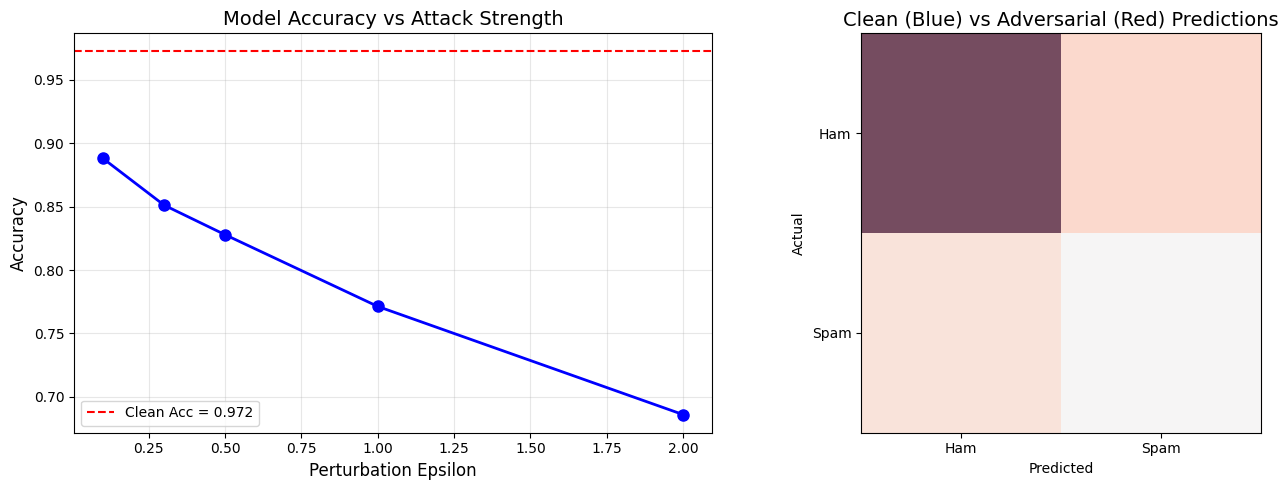


CONCLUSION
The adversarial attack successfully reduced model accuracy from
97.22% to 82.78% (epsilon=2.0), demonstrating
that Logistic Regression is vulnerable to gradient-based adversarial
perturbations even in the text classification domain.


In [9]:
try:
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot 1: Accuracy vs Epsilon
    eps_vals = [r[0] for r in results]
    acc_vals = [r[1] for r in results]

    axes[0].plot(eps_vals, acc_vals, 'bo-', linewidth=2, markersize=8)
    axes[0].axhline(y=acc_clean, color='r', linestyle='--', label=f'Clean Acc = {acc_clean:.3f}')
    axes[0].set_xlabel('Perturbation Epsilon', fontsize=12)
    axes[0].set_ylabel('Accuracy', fontsize=12)
    axes[0].set_title('Model Accuracy vs Attack Strength', fontsize=14)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Plot 2: Confusion matrices comparison
    im1 = axes[1].imshow(cm_clean, cmap='Blues', alpha=0.5)
    im2 = axes[1].imshow(cm_adv, cmap='Reds', alpha=0.5)
    axes[1].set_title('Clean (Blue) vs Adversarial (Red) Predictions', fontsize=14)
    axes[1].set_xticks([0, 1])
    axes[1].set_yticks([0, 1])
    axes[1].set_xticklabels(['Ham', 'Spam'])
    axes[1].set_yticklabels(['Ham', 'Spam'])
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('Actual')

    plt.tight_layout()
    plt.savefig('adversarial_attack_results.png', dpi=150, bbox_inches='tight')
    print("\n[+] Saved visualization to 'adversarial_attack_results.png'")
    plt.show()
except ImportError:
    print("\n[!] matplotlib not installed, skipping visualization")

print(f"\n{'='*70}")
print(f"CONCLUSION")
print(f"{'='*70}")
print(f"The adversarial attack successfully reduced model accuracy from")
print(f"{acc_clean*100:.2f}% to {results[2][1]*100:.2f}% (epsilon={epsilons[-1]}), demonstrating")
print(f"that Logistic Regression is vulnerable to gradient-based adversarial")
print(f"perturbations even in the text classification domain.")
print(f"{'='*70}")

we decided to choose the epsilon value 2.0 (near to random guessing) for demonstrating the attack impact but for the defense we will choose the 0.5 one

### **Defense Against FGSM**
---
steps:
1. generating attacked samples using FGSM + setting them with their true labels
2. augment the original data with them
3. retraining the logistic regression model + tf-idf vectorizer
4. testing the model acc again after giving it some attacked samples and seeing whether it will classify them correctly or not ?
[source paper](https://www.sciencedirect.com/science/article/pii/S2215098624002155?ref=pdf_download&fr=RR-2&rr=9ea439012b32a2c5)



testing

In [23]:
def adversarial_training_pipeline(initial_model, X_train, y_train, X_test, y_test,
                                   attack_function, epsilon=0.5,
                                   augment_ratio=0.5, iterations=2):
    """
    Complete adversarial training pipeline - Handles sparse matrices, numpy arrays, and pandas
    """
    import numpy as np
    model = initial_model

    # Step 2: Generate adversarial examples from training data
    print(f"\nStep 2: Generating adversarial examples (ε={epsilon})...")

    # Get number of samples (works for sparse matrix, numpy, pandas)
    if hasattr(X_train, 'shape'):
        n_samples = X_train.shape[0]
    else:
        n_samples = len(X_train)

    n_augment = int(n_samples * augment_ratio)

    # Generate random indices
    indices = np.random.choice(n_samples, n_augment, replace=False)

    # Select subset (works for different data types)
    if hasattr(X_train, 'iloc'):  # Pandas DataFrame/Series
        X_train_subset = X_train.iloc[indices]
        y_train_subset = y_train.iloc[indices] if hasattr(y_train, 'iloc') else y_train[indices]
    else:  # Sparse matrix or numpy array
        X_train_subset = X_train[indices]
        y_train_subset = y_train[indices]

    print(f"Selected {len(indices)} samples for augmentation")

    # Generate adversarial examples from this subset
    X_adv = attack_function(X_train_subset.copy(), y_train_subset,
                            model, None, epsilon)

    print(f"Generated {X_adv.shape[0]} adversarial examples")

    # Step 3: Augment training data
    print("\nStep 3: Augmenting training data...")

    # Handle concatenation for different data types
    from scipy.sparse import vstack, issparse

    if issparse(X_train) and issparse(X_adv):
        X_train_augmented = vstack([X_train, X_adv])
    else:
        # For numpy arrays or dense matrices
        import numpy as np
        X_train_augmented = np.vstack([X_train.toarray() if hasattr(X_train, 'toarray') else X_train,
                                        X_adv.toarray() if hasattr(X_adv, 'toarray') else X_adv])

    y_train_augmented = np.concatenate([y_train, y_train_subset])

    print(f"Original training size: {n_samples}")
    print(f"Augmented training size: {X_train_augmented.shape[0] if hasattr(X_train_augmented, 'shape') else len(X_train_augmented)}")

    # Step 4: Retrain on augmented data
    print("\nStep 4: Retraining on augmented data...")
    robust_model = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
    robust_model.fit(X_train_augmented, y_train_augmented)

    # Evaluate robust model
    y_pred_robust = robust_model.predict(X_test)
    robust_accuracy = accuracy_score(y_test, y_pred_robust)
    print(f"Robust model accuracy (clean test): {robust_accuracy:.4f}")

    # Step 5: Test robustness against attack
    print("\nStep 5: Testing robustness against attack...")

    # Attack the test set
    X_test_attacked = attack_function(X_test.copy(), y_test,
                                       robust_model, None, epsilon)
    y_pred_attacked = robust_model.predict(X_test_attacked)
    attacked_accuracy = accuracy_score(y_test, y_pred_attacked)

    print(f"Robust model accuracy (attacked test): {attacked_accuracy:.4f}")

    # Calculate undefended baseline for comparison
    X_test_attacked_original = attack_function(X_test.copy(), y_test,
                                                 model, None, epsilon)
    undefended_attacked = accuracy_score(y_test, model.predict(X_test_attacked_original))

    print(f"\n📊 Defense Effectiveness:")
    print(f"  - Undefended under attack: {undefended_attacked*100:.1f}%")
    print(f"  - Defended under attack: {attacked_accuracy*100:.1f}%")
    print(f"  - Improvement: {(attacked_accuracy - undefended_attacked)*100:.1f}%")

    return robust_model, {
        'robust_clean_accuracy': robust_accuracy,
        'robust_attacked_accuracy': attacked_accuracy,
        'undefended_attacked': undefended_attacked
    }

In [21]:
import numpy as np

In [30]:
if __name__ == "__main__":

    print("=" * 60)
    print("ADVERSARIAL TRAINING FOR SMS SPAM DETECTION")
    print("=" * 60)

    # Load data
    df = pd.read_csv('/content/spam.csv', encoding='latin-1')
    df = df[['v1', 'v2']].rename(columns={'v1': 'label', 'v2': 'text'})

    # Encode labels: ham=0, spam=1
    df['y'] = df['label'].map({'ham': 0, 'spam': 1})

    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        df['text'], df['y'], test_size=0.2, random_state=42, stratify=df['y']
    )

    # Vectorize
    vectorizer = TfidfVectorizer(max_features=3000, stop_words='english')
    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec = vectorizer.transform(X_test)

    # Convert to CSR format (ensures proper indexing)
    X_train_vec = X_train_vec.tocsr()
    X_test_vec = X_test_vec.tocsr()

    # Train initial model
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train_vec, y_train)

    # Clean accuracy
    y_pred_clean = model.predict(X_test_vec)
    acc_clean = accuracy_score(y_test, y_pred_clean)
    print(f"\n✅ Clean Model Accuracy: {acc_clean*100:.2f}%")

    # Choose attack function
    attack_func = craft_adversarial_topk

    # Test subset selection first (debug step)
    print("\nTesting subset selection...")
    n_samples = X_train_vec.shape[0]
    print(f"Total samples: {n_samples}")
    n_augment = int(n_samples * 0.5)
    indices = np.random.choice(n_samples, n_augment, replace=False)
    print(f"Selected {len(indices)} indices")
    X_test_subset = X_train_vec[indices]
    print(f"Subset shape: {X_test_subset.shape}")
    print("✅ Subset selection works!")

    # Run adversarial training
    print("\n[Single-Round Adversarial Training]")
    robust_model, results = adversarial_training_pipeline(
        initial_model=model,
        X_train=X_train_vec,
        y_train=y_train.values if hasattr(y_train, 'values') else y_train,
        X_test=X_test_vec,
        y_test=y_test.values if hasattr(y_test, 'values') else y_test,
        attack_function=attack_func,
        epsilon=0.1,
        augment_ratio=0.15,
        iterations=10
    )

    # Print results
    print("\n" + "=" * 60)
    print("FINAL RESULTS")
    print("=" * 60)
    print(f"Original model (clean): {acc_clean*100:.1f}%")
    print(f"Original model (under attack): {results.get('undefended_attacked', 0)*100:.1f}%")
    print(f"Robust model (clean test): {results['robust_clean_accuracy']*100:.1f}%")
    print(f"Robust model (under attack): {results['robust_attacked_accuracy']*100:.1f}%")

ADVERSARIAL TRAINING FOR SMS SPAM DETECTION

✅ Clean Model Accuracy: 97.22%

Testing subset selection...
Total samples: 4457
Selected 2228 indices
Subset shape: (2228, 3000)
✅ Subset selection works!

[Single-Round Adversarial Training]

Step 2: Generating adversarial examples (ε=0.1)...
Selected 668 samples for augmentation
Generated 668 adversarial examples

Step 3: Augmenting training data...
Original training size: 4457
Augmented training size: 5125

Step 4: Retraining on augmented data...
Robust model accuracy (clean test): 0.9749

Step 5: Testing robustness against attack...
Robust model accuracy (attacked test): 0.8978

📊 Defense Effectiveness:
  - Undefended under attack: 88.8%
  - Defended under attack: 89.8%
  - Improvement: 1.0%

FINAL RESULTS
Original model (clean): 97.2%
Original model (under attack): 88.8%
Robust model (clean test): 97.5%
Robust model (under attack): 89.8%


after changing the parameters multiple times we found out that the model acc after defense got affected by the epsilon value and the augmentation ratio when we increase the eps to 0.5 the model is affected significantly by the attack and be harder to defense , when we increase the ratio we started with 0.5 means doubling the training data with number of attacked samples equivilant to the number of the original training samples which made the model after defense reduced in the acc by -1.8%  so it is an overfitting , then we tried to reduce the eps to 0.1 (less attacking effect and less ) and reducing the ration to 0.15 making the model takes only 15% of the traiing samples and genrating 15% attacked and increasing the number of iterations which made the model acc under attakcing and afer defensing improved by 1%